In [1]:
import tensorflow as tf
from keras.models import Model, Sequential
from keras.layers import Activation, Dense, BatchNormalization, concatenate, Dropout, Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Input, Reshape
from keras.callbacks import EarlyStopping
from keras.layers.core import SpatialDropout2D
from keras import backend as K
from tensorflow.keras.optimizers import Adam, RMSprop
import numpy as np
import pandas as pd
import glob
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import cv2
%matplotlib inline
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras import layers
from keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from warnings import filterwarnings
from keras.models import load_model
import itertools 
import random
def set_seed(seed):
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    random.seed(seed)


seed = 42
set_seed(seed)
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.mixed_precision import experimental as mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_policy(policy)
print('Compute dtype: %s' % policy.compute_dtype)
print('Variable dtype: %s' % policy.variable_dtype)

In [2]:
train_dir = "train"
test_dir = "test"
val_dir= "val"

In [3]:
model1 = MobileNetV2(include_top=False,input_shape=(224, 224,3), weights='imagenet')
input_shape = (224, 224)

In [4]:
datagen_train = ImageDataGenerator(rescale=1./255,
                                  width_shift_range=0.1,
                                  height_shift_range=0.1,
                                  horizontal_flip=True,
                                  vertical_flip=False)



datagen_test = ImageDataGenerator(rescale=1./255)

datagen_val=ImageDataGenerator(rescale=1./255)

batch_size = 20
generator_train = datagen_train.flow_from_directory(directory=train_dir,
                                                    target_size=input_shape,
                                                    batch_size=batch_size,  
                                                    class_mode='categorical',
                                                    shuffle=True)

generator_val = datagen_val.flow_from_directory(directory=val_dir,
                                                  target_size=input_shape,
                                                  batch_size=batch_size,
                                                class_mode='categorical',
                                                  shuffle=True)
generator_test=datagen_test.flow_from_directory(directory=test_dir,
                                                  target_size=input_shape,
                                                 batch_size=batch_size,
                                                class_mode='categorical',
                                                 shuffle=False)

Found 3248 images belonging to 4 classes.
Found 409 images belonging to 4 classes.
Found 405 images belonging to 4 classes.


In [5]:
len(model1.layers)

154

In [6]:
def print_layer_trainable():
    for layer in model1.layers[:-1]:
        layer.trainable=False
        print("{0}:\t{1}".format(layer.trainable, layer.name))


print_layer_trainable()

False:	input_1
False:	Conv1
False:	bn_Conv1
False:	Conv1_relu
False:	expanded_conv_depthwise
False:	expanded_conv_depthwise_BN
False:	expanded_conv_depthwise_relu
False:	expanded_conv_project
False:	expanded_conv_project_BN
False:	block_1_expand
False:	block_1_expand_BN
False:	block_1_expand_relu
False:	block_1_pad
False:	block_1_depthwise
False:	block_1_depthwise_BN
False:	block_1_depthwise_relu
False:	block_1_project
False:	block_1_project_BN
False:	block_2_expand
False:	block_2_expand_BN
False:	block_2_expand_relu
False:	block_2_depthwise
False:	block_2_depthwise_BN
False:	block_2_depthwise_relu
False:	block_2_project
False:	block_2_project_BN
False:	block_2_add
False:	block_3_expand
False:	block_3_expand_BN
False:	block_3_expand_relu
False:	block_3_pad
False:	block_3_depthwise
False:	block_3_depthwise_BN
False:	block_3_depthwise_relu
False:	block_3_project
False:	block_3_project_BN
False:	block_4_expand
False:	block_4_expand_BN
False:	block_4_expand_relu
False:	block_4_depthwise
Fa

In [7]:
headModel = model1.output
headModel = layers.Flatten()(headModel)
# headModel = Dense(1024, activation="relu")(headModel)
headModel = Dense(512, activation="relu")(headModel)
# headModel = Dense(256, activation="relu")(headModel)
headModel = Dropout(.4)(headModel)
headModel = Dense(4, activation="softmax")(headModel)
model = Model(inputs=model1.input, outputs=headModel)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                                             

 block_3_expand_relu (ReLU)     (None, 56, 56, 144)  0           ['block_3_expand_BN[0][0]']      
                                                                                                  
 block_3_pad (ZeroPadding2D)    (None, 57, 57, 144)  0           ['block_3_expand_relu[0][0]']    
                                                                                                  
 block_3_depthwise (DepthwiseCo  (None, 28, 28, 144)  1296       ['block_3_pad[0][0]']            
 nv2D)                                                                                            
                                                                                                  
 block_3_depthwise_BN (BatchNor  (None, 28, 28, 144)  576        ['block_3_depthwise[0][0]']      
 malization)                                                                                      
                                                                                                  
 block_3_d

 lization)                                                                                        
                                                                                                  
 block_7_expand (Conv2D)        (None, 14, 14, 384)  24576       ['block_6_project_BN[0][0]']     
                                                                                                  
 block_7_expand_BN (BatchNormal  (None, 14, 14, 384)  1536       ['block_7_expand[0][0]']         
 ization)                                                                                         
                                                                                                  
 block_7_expand_relu (ReLU)     (None, 14, 14, 384)  0           ['block_7_expand_BN[0][0]']      
                                                                                                  
 block_7_depthwise (DepthwiseCo  (None, 14, 14, 384)  3456       ['block_7_expand_relu[0][0]']    
 nv2D)    

                                                                                                  
 block_10_depthwise_relu (ReLU)  (None, 14, 14, 384)  0          ['block_10_depthwise_BN[0][0]']  
                                                                                                  
 block_10_project (Conv2D)      (None, 14, 14, 96)   36864       ['block_10_depthwise_relu[0][0]']
                                                                                                  
 block_10_project_BN (BatchNorm  (None, 14, 14, 96)  384         ['block_10_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_11_expand (Conv2D)       (None, 14, 14, 576)  55296       ['block_10_project_BN[0][0]']    
                                                                                                  
 block_11_

 block_14_depthwise (DepthwiseC  (None, 7, 7, 960)   8640        ['block_14_expand_relu[0][0]']   
 onv2D)                                                                                           
                                                                                                  
 block_14_depthwise_BN (BatchNo  (None, 7, 7, 960)   3840        ['block_14_depthwise[0][0]']     
 rmalization)                                                                                     
                                                                                                  
 block_14_depthwise_relu (ReLU)  (None, 7, 7, 960)   0           ['block_14_depthwise_BN[0][0]']  
                                                                                                  
 block_14_project (Conv2D)      (None, 7, 7, 160)    153600      ['block_14_depthwise_relu[0][0]']
                                                                                                  
 block_14_

In [8]:
optimizer = Adam(lr=1e-4)
loss = 'categorical_crossentropy'
metrics = ['accuracy','Precision','Recall']


model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

C:\Users\hkmeh\anaconda3\envs\tf\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [9]:
from tensorflow.keras.callbacks import EarlyStopping

epochs =25

steps_per_epoch = generator_train.n / batch_size
steps_test = generator_test.n / batch_size

# steps_per_epoch = 20
# steps_test = 20
early_stop = EarlyStopping(patience=2)
history = model.fit_generator(generator=generator_train,
                              epochs=epochs,
                              steps_per_epoch=steps_per_epoch,
                              validation_data=generator_val,
                              validation_steps=steps_test
                             
                             )


C:\Users\hkmeh\AppData\Local\Temp\ipykernel_18940\1020489043.py:11: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(generator=generator_train,


Epoch 1/25
162/162 [==============================] - 26s 138ms/step - loss: 0.5402 - accuracy: 0.8935 - precision: 0.8962 - recall: 0.8904 - val_loss: 0.0909 - val_accuracy: 0.9682 - val_precision: 0.9682 - val_recall: 0.9682
Epoch 2/25
162/162 [==============================] - 21s 127ms/step - loss: 0.1274 - accuracy: 0.9612 - precision: 0.9614 - recall: 0.9597 - val_loss: 0.1605 - val_accuracy: 0.9487 - val_precision: 0.9487 - val_recall: 0.9487
Epoch 3/25
162/162 [==============================] - 21s 127ms/step - loss: 0.0823 - accuracy: 0.9704 - precision: 0.9707 - recall: 0.9704 - val_loss: 0.3344 - val_accuracy: 0.9071 - val_precision: 0.9071 - val_recall: 0.9071
Epoch 4/25
162/162 [==============================] - 21s 127ms/step - loss: 0.1199 - accuracy: 0.9627 - precision: 0.9633 - recall: 0.9615 - val_loss: 0.0792 - val_accuracy: 0.9731 - val_precision: 0.9755 - val_recall: 0.9731
Epoch 5/25
162/162 [==============================] - 21s 127ms/step - loss: 0.0872 - accura

In [10]:
model.save("MobileNetV2.h5")

In [21]:
#Get the accuracy score

train_score = model.evaluate_generator(generator_train)



print("[INFO] accuracy: {:.2f}%".format(train_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(train_score[0] * 100)) 

C:\Users\hkmeh\AppData\Local\Temp\ipykernel_18940\394253807.py:3: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  train_score = model.evaluate_generator(generator_train)


[INFO] accuracy: 98.89%
[INFO] Loss: 2.93%


In [22]:
#Get the accuracy score

test_score = model.evaluate_generator(generator_test)



print("[INFO] accuracy: {:.2f}%".format(test_score[1] * 100)) 

print("[INFO] Loss: {:.2f}%".format(test_score[0] * 100)) 
test_score

C:\Users\hkmeh\AppData\Local\Temp\ipykernel_18940\3068023983.py:3: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  test_score = model.evaluate_generator(generator_test)


[INFO] accuracy: 98.02%
[INFO] Loss: 5.12%


[0.051158320158720016, 0.980246901512146, 0.980246901512146, 0.980246901512146]

In [12]:

classes=list(generator_train.class_indices.keys())
class_count=len(classes)
print(class_count)
li=[1,2,3,4]

4


C:\Users\hkmeh\AppData\Local\Temp\ipykernel_18940\880947260.py:5: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = model.predict_generator(generator_test)


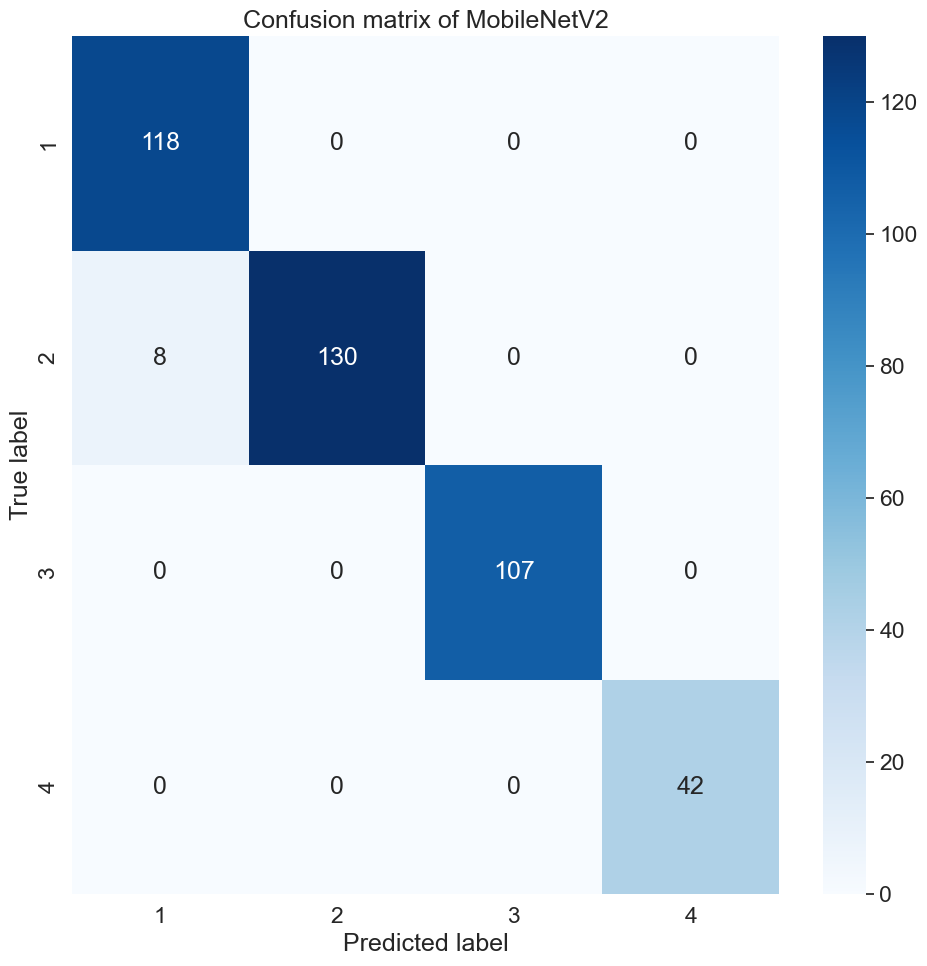

In [13]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
Y_pred = model.predict_generator(generator_test)
y_pred = np.argmax(Y_pred, axis=1)
array = confusion_matrix(generator_test.classes, y_pred)
df_cm = pd.DataFrame(array, index =li,
                  columns = li)
plt.figure(figsize=(10,10))
sn.set(font_scale=1.5)
sn.heatmap(df_cm, annot=True, cmap='Blues', fmt='g')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion matrix of MobileNetV2')
plt.tight_layout()
# plt.savefig('MobileNetV2_confusion',dpi=200); 
plt.show()



In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(generator_test.classes, y_pred)

0.980246913580247

In [15]:
target_names = []

for key in generator_train.class_indices:

    target_names.append(key)



print(target_names)

['Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy']


In [16]:
print(classification_report(generator_test.classes, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       118
           1       1.00      0.94      0.97       138
           2       1.00      1.00      1.00       107
           3       1.00      1.00      1.00        42

    accuracy                           0.98       405
   macro avg       0.98      0.99      0.98       405
weighted avg       0.98      0.98      0.98       405



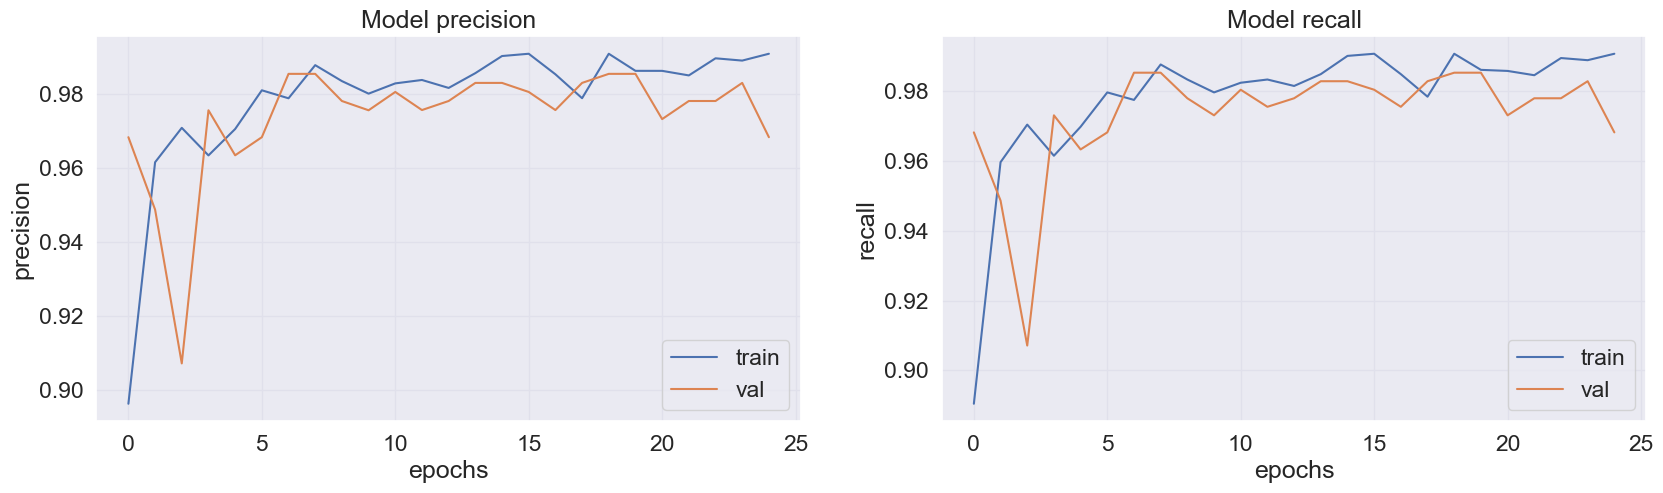

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()

for i, met in enumerate(['precision', 'recall']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'])

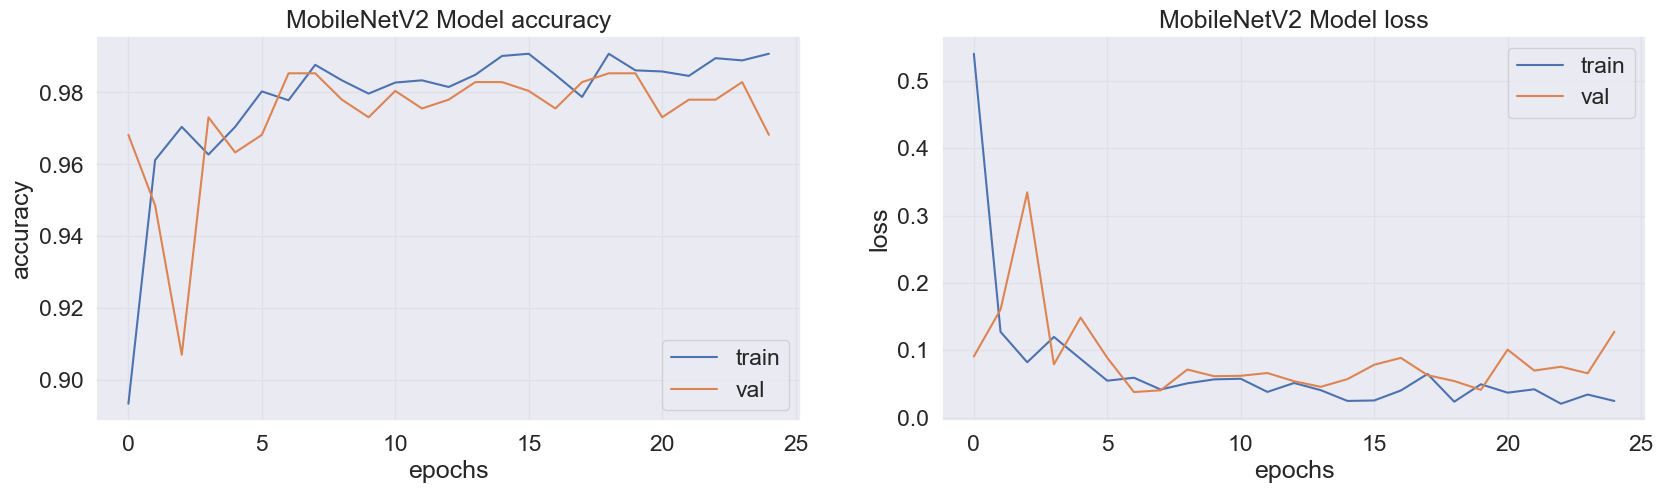

In [18]:

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
ax = ax.ravel()
for i, met in enumerate([ 'accuracy', 'loss']):
    ax[i].plot(history.history[met])
    ax[i].plot(history.history['val_' + met])
    ax[i].set_title('MobileNetV2 Model {}'.format(met))
    ax[i].set_xlabel('epochs')
    ax[i].set_ylabel(met)
    ax[i].grid(color = '#e0e0eb')
    ax[i].legend(['train', 'val'],loc='best')
plt.show()

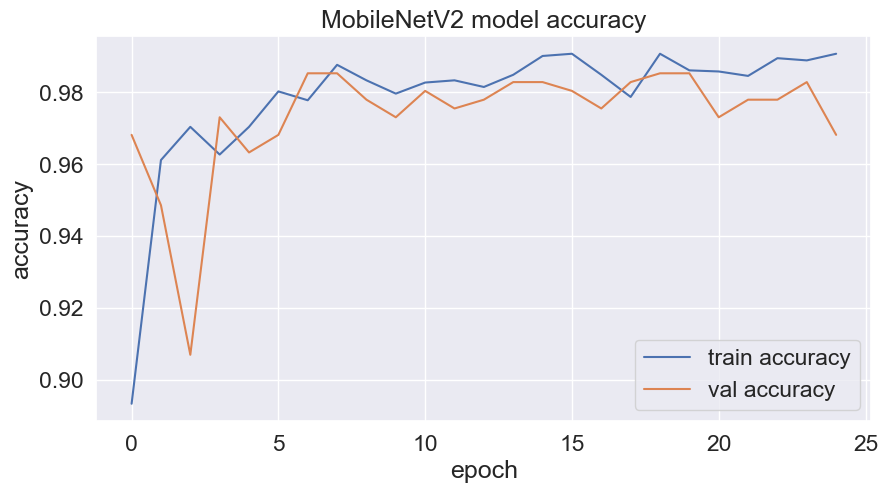

In [19]:

plt.figure(figsize=(10, 5))
ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['accuracy'],label="train accuracy")
plt.plot(history.history['val_accuracy'],label="val accuracy")
plt.title('MobileNetV2 model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
# plt.savefig('MobileNetV2_accuracy',dpi=200); 
plt.show()


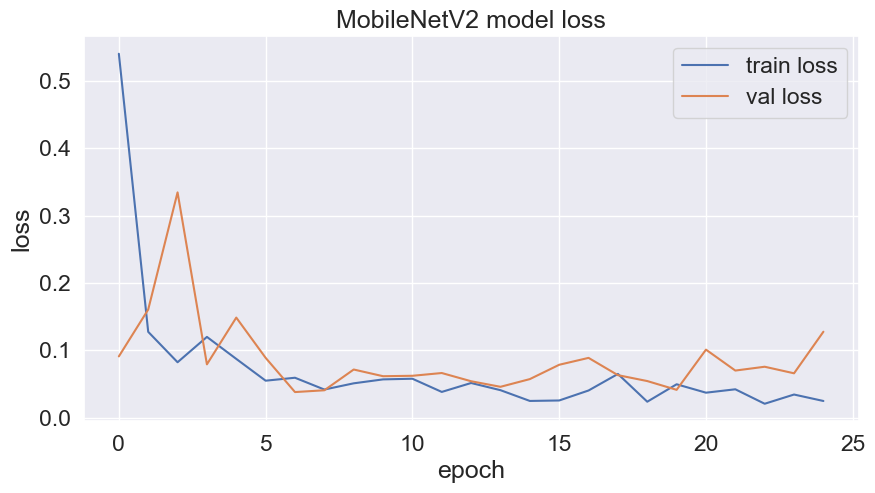

In [20]:
plt.figure(figsize=(10, 5))

ax = plt.axes()
ax.set_facecolor("#eaeaf2")
plt.plot(history.history['loss'],label="train loss")
plt.plot(history.history['val_loss'],label="val loss")
plt.title('MobileNetV2 model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.grid(color = 'w')
# plt.savefig('MobileNetV2_loss',dpi=200); 
plt.show()